# Project - Deep Image Prior

## Description

### Objective

Implement a convolutional neural network for image reconstruction using the [Deep Image Prior](https://arxiv.org/abs/1711.10925) framework.

The objectives of this project are to:

1. Reconstruct an image from a fixed random noise input.
2. Explore how CNN architectures can act as implicit image priors.
3. Perform image restoration without using any training data.

### Data

Deep Image Prior does not require a dataset.

The network is optimized on a single image:

- Input: Random noise tensor
- Target: Image to reconstruct or restore

### Model

The model consists of a fully convolutional neural network with multiple 3×3 convolutional layers and ReLU activations. The network maps a fixed noise input to an output image of the same size as the target image.

### Method

The network parameters are optimized to minimize the reconstruction error between the generated image and the target image:

$$
\theta^* = \arg\min_\theta \|f_\theta(z) - x\|^2
$$

where $z$ is fixed random noise and $x$ is the target image.

In [1]:
from pathlib import Path

import torch
from torch.utils.data import DataLoader, Dataset

from eigen.data import add_gaussian_noise, load_image
from eigen.metrics import mean_squared_error
from eigen.plotting import plot_image_grid
from eigen.trainer import Trainer
from models.deep_image_prior import DeepImagePrior

In [2]:
torch.manual_seed(0)
SIGMA = 0.5
PATH = Path("../data/snail.jpg")
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [3]:
class OneImageDataset(Dataset):
    def __init__(self, img: torch.Tensor, img_label: torch.Tensor) -> None:
        self.img = img
        self.img_label = img_label

    def __len__(self) -> int:
        return 1

    def __getitem__(self, _) -> tuple[torch.Tensor, torch.Tensor]:
        return self.img, self.img_label

Shape:  torch.Size([3, 261, 400])


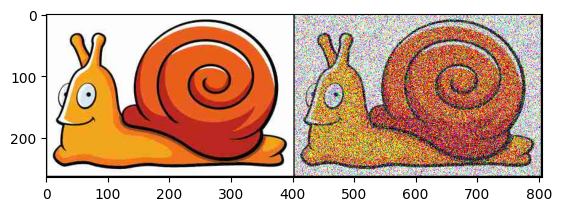

(<Figure size 640x480 with 1 Axes>, <Axes: >)

In [ ]:
img = load_image(PATH)
C, W, H = img.shape
print("Shape: ", img.shape)
img_noisy = torch.clip(add_gaussian_noise(img, SIGMA), 0, 1)
# display noisy image
plot_image_grid([img, img_noisy]);

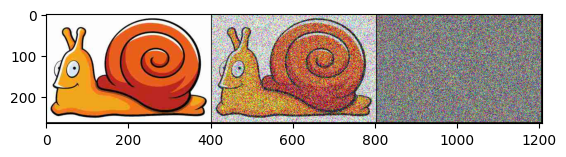

(<Figure size 640x480 with 1 Axes>, <Axes: >)

In [ ]:
# model initialization
model = DeepImagePrior(C)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()

trainer = Trainer(
    model,
    optimizer,
    criterion,
    metrics={"mse": mean_squared_error},
    n_epochs=2500,
    device=device,
)

z = torch.rand(C, W, H, device=device)
plot_image_grid([img, img_noisy, z.to("cpu")]);

In [6]:
%%capture
# training
train_loader = DataLoader(OneImageDataset(z, img_noisy), batch_size=1, shuffle=False)
trainer.fit(train_loader, train_loader)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4576311].


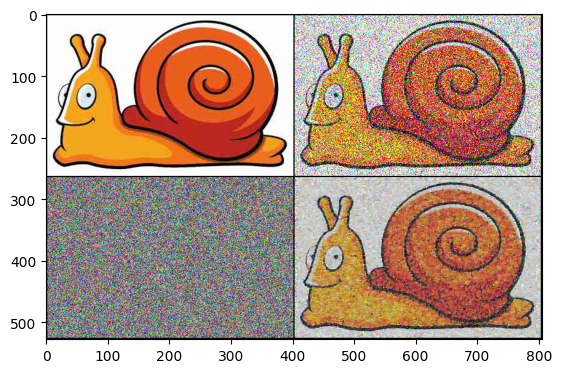

In [7]:
# inference
output = model(z).detach().to("cpu")
plot_image_grid([img, img_noisy, z.to("cpu"), output], grid_kws=dict(nrow=2));

In [8]:
# serialize model to onnx
torch.onnx.export(
    model,
    (z,),
    "../checkpoints/DeepImagePrior/deep_image_prior.onnx",
    input_names=["input"],
    output_names=["output"],
);

[torch.onnx] Obtain model graph for `DeepImagePrior([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DeepImagePrior([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
